# 24/05/2026 ML Pipeline for EEG data classification on the Kuo & Prat (2023) data set.
# **SUBJECT-LEVEL/INTRA-SUBJECT ERP CLASSIFICATION**

ML MODELS:
*   Linear Discriminant Analysis (LDA) - Ledoit Wolf
*   Suuport Vector Machine (SVM) - linear/radial
*   Random Forest (RF)

## 1. Environment + Data Loading

Step 1.1: Global imports and Google Drive mounting.

Step 1.2: Metadata filtering and .set file loading via MNE.

Step 1.3: Feature Extraction (isolating the 500-800ms P600 ROI, extracting 2D matrices).

In [2]:
!pip install -q mne scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 93.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import mne
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

from google.colab import drive
from scipy.stats import mannwhitneyu

# Scikit-Learn core pipeline and evaluation modules
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    permutation_test_score,
    GridSearchCV
)
from sklearn.metrics import confusion_matrix

# Scikit-Learn discriminative models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [4]:
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/EEG_data/full_subject_list"
EPOCHS_DIR = BASE_DIR
METADATA_PATH = os.path.join(BASE_DIR,"participants.tsv")
print("--- ENVIRONMENT LOADED ---")
print(f"Base Directory: {BASE_DIR}")
print(f"Metadata Path: {METADATA_PATH}")
print(f"MNE Version: {mne.__version__}")

Mounted at /content/drive
--- ENVIRONMENT LOADED ---
Base Directory: /content/drive/MyDrive/EEG_data/full_subject_list
Metadata Path: /content/drive/MyDrive/EEG_data/full_subject_list/participants.tsv
MNE Version: 1.12.1


In [5]:
print("--- PROCESSING METADATA ---")
try:
    meta_df = pd.read_csv(METADATA_PATH, sep='\t')

    if 'data_usability' in meta_df.columns:
        valid_meta_df = meta_df[meta_df['data_usability'] == 'good'].copy()
        print(f"Filtered out {len(meta_df) - len(valid_meta_df)} unusable subjects.")
    else:
        valid_meta_df = meta_df.copy()
        print("Warning: 'data_usability' not found. Proceeding with all subjects.")

    print(f"Usable subjects retained: {valid_meta_df.shape[0]}")
    print(f"Group distribution:\n{valid_meta_df['python_expertise'].value_counts()}\n")

    # Mapping the expertise for later extraction
    expertise_map = dict(zip(valid_meta_df['participant_id'], valid_meta_df['python_expertise']))

except Exception as e:
    print(f"Metadata Initialization Error: {e}")

--- PROCESSING METADATA ---
Filtered out 16 unusable subjects.
Usable subjects retained: 45
Group distribution:
python_expertise
Expert    27
Novice    18
Name: count, dtype: int64



In [6]:
# DATA LOADING

# 2D vector matrix
subject_epochs = {}
subject_labels = {}

# tracking the variables (how many epochs in total, average length)
total_global_epochs = 0
epoch_time_window = None

print("\n--- LOADING .SET FILES ---")
for sub_id in valid_meta_df['participant_id']:
    search_pattern = os.path.join(EPOCHS_DIR, sub_id, '**', '*.set')
    set_files = glob.glob(search_pattern, recursive=True)

    if not set_files:
        print(f"Warning: No .set file found for {sub_id}. Skipping.")
        continue

    set_file_path = set_files[0]
    expertise = expertise_map.get(sub_id, "Unknown")

    try:
        # LOADING THE EPOCHS FROM THE EEGLAB STRUCTURE
        epochs = mne.io.read_epochs_eeglab(set_file_path, verbose=False)

        # Capture epoch temporal length (tmax - tmin) from the first subject
        if epoch_time_window is None:
            epoch_time_window = np.round(epochs.times[-1] - epochs.times[0], 3)

        # Target triggers (Valid = 110/115, Invalid = 220/225)
        valid_codes = [code for label, code in epochs.event_id.items() if '110' in label or '115' in label]
        invalid_codes = [code for label, code in epochs.event_id.items() if '220' in label or '225' in label]

        if not valid_codes or not invalid_codes:
            print(f"Warning: Target triggers missing in {sub_id}. Skipping.")
            continue

        # filtering the epochs array
        combined_codes = valid_codes + invalid_codes
        epochs_filtered = epochs[np.isin(epochs.events[:, 2], combined_codes)]

        # Construct target vector y: Valid -> 0, Invalid -> 1
        filtered_events = epochs_filtered.events[:, 2]
        y = np.array([0 if ev in valid_codes else 1 for ev in filtered_events])

        # storing in dict
        subject_epochs[sub_id] = epochs_filtered
        subject_labels[sub_id] = y

        # global epoch count
        total_global_epochs += len(y)

        print(f"Loaded {sub_id} ({expertise}) | Epochs: {len(y)} | Valid(0): {np.sum(y==0)} | Invalid(1): {np.sum(y==1)}")

    except Exception as e:
        print(f"Error processing {sub_id}: {e}")

print("\n--- DATA LOADING SUMMARY ---")
print(f"Successfully mapped data for {len(subject_epochs)} subjects.")
print(f"Total aggregate epochs across all valid subjects: {total_global_epochs}")
print(f"Standard Epoch Duration (tmax - tmin): {epoch_time_window} seconds")


--- LOADING .SET FILES ---
Loaded sub-001 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-002 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-003 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-004 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-005 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-006 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-008 (Expert) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-010 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-011 (Expert) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-012 (Expert) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-013 (Expert) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-014 (Novice) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-015 (Expert) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded sub-016 (Expert) | Epochs: 80 | Valid(0): 40 | Invalid(1): 40
Loaded

In [7]:
# FEATURE EXTRACTION

print("--- EXTRACTING P600 FEATURES ---")

p600_roi = ['Fz', 'Cz', 'Pz', 'FC1', 'FC2', 'CP1', 'CP2']
# based on the Kuo&Prat (2024) Supplementary Table
subject_features = {}

for sub_id, epochs in subject_epochs.items():
    try:
        # temporal filtering (500ms - 800ms) + spatial filtering
        epochs_roi = epochs.copy().pick(p600_roi).crop(tmin=0.5, tmax=0.8)

        # extract 3D tensor
        X_3d = epochs_roi.get_data()

        # temporal averaging across the time axis (axis=2)
        X_2d = np.mean(X_3d, axis=2)

        subject_features[sub_id] = X_2d

        if sub_id == list(subject_epochs.keys())[0]:
            print(f"Dimensionality Check for {sub_id}:")
            print(f"  3D Tensor: {X_3d.shape} (Epochs, Channels, Timepoints)")
            print(f"  2D Matrix: {X_2d.shape} (Epochs, Features/Channels)")

    except Exception as e:
        print(f"Error extracting features for {sub_id}: {e}")

print(f"\nFeature extraction complete for {len(subject_features)} subjects.")

--- EXTRACTING P600 FEATURES ---
Dimensionality Check for sub-001:
  3D Tensor: (80, 7, 78) (Epochs, Channels, Timepoints)
  2D Matrix: (80, 7) (Epochs, Features/Channels)

Feature extraction complete for 45 subjects.


## 2. Baseline Model Classification

Evaluating the results of three baseline models (DEFAULT SETTING: no hyperparameter tuning)

In [8]:
from sklearn.model_selection import cross_val_score

print("--- INITIALIZING BASELINE MODELS ---")

# DISCRIMINATIVE MODELS WITH DEFAULT PARAMETERS
baseline_models = {
    'LDA': LinearDiscriminantAnalysis(),
    'SVM-Linear': SVC(kernel='linear', class_weight='balanced', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# cross-validation (4 training sets, 1 test set)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# dicts to store the metrics
baseline_results = {
    name: {
        'all_acc': [],
        'aggregate_cm': np.zeros((2, 2)),
        'Expert_acc': [],
        'Novice_acc': []
    } for name in baseline_models.keys()
}

--- INITIALIZING BASELINE MODELS ---


In [9]:
print("--- EXECUTING INTRA-SUBJECT CV (BASELINE MODELS ) ---")

for sub_id, X in subject_features.items():
    y = subject_labels[sub_id]
    expertise = expertise_map.get(sub_id, "Unknown")

    for model_name, clf in baseline_models.items():
        # STRICT SCALING, StandardScaler applied ONLY within the training fold
        # to prevent data leakage from the validation fold.
        pipeline = make_pipeline(StandardScaler(), clf)

        # k-fold evaluation
        scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        mean_score = np.mean(scores)

        # generating predictions
        y_pred = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)
        cm = confusion_matrix(y, y_pred, labels=[0, 1])

        # METRICS
        baseline_results[model_name]['all_acc'].append(mean_score)
        baseline_results[model_name]['aggregate_cm'] += cm

        # GROUP SEPERATION BY PYTHON EXPERTISE
        if expertise == 'Expert':
            baseline_results[model_name]['Expert_acc'].append(mean_score)
        elif expertise == 'Novice':
            baseline_results[model_name]['Novice_acc'].append(mean_score)

print("--- BASELINE RESULTS SUMMARY ---")

for model_name in baseline_models.keys():
    acc_array = baseline_results[model_name]['all_acc']
    mean_acc = np.mean(acc_array)

    exp_acc = baseline_results[model_name]['Expert_acc']
    nov_acc = baseline_results[model_name]['Novice_acc']

    mean_exp = np.mean(exp_acc) if exp_acc else 0
    mean_nov = np.mean(nov_acc) if nov_acc else 0

    # Non-parametric independent test (Expert > Novice)
    try:
        stat, p_mw = mannwhitneyu(exp_acc, nov_acc, alternative='greater')
    except ValueError:
        p_mw = 1.0

    print(f"MODEL: {model_name}")
    print(f"  Global Mean Accuracy: {mean_acc:.3f}")
    print(f"  Expert Mean: {mean_exp:.3f} | Novice Mean: {mean_nov:.3f}")
    print(f"  Mann-Whitney U p-val (Expert > Novice): {p_mw:.3f}\n")

--- EXECUTING INTRA-SUBJECT CV (BASELINE MODELS ) ---
--- BASELINE RESULTS SUMMARY ---
MODEL: LDA
  Global Mean Accuracy: 0.545
  Expert Mean: 0.561 | Novice Mean: 0.522
  Mann-Whitney U p-val (Expert > Novice): 0.109

MODEL: SVM-Linear
  Global Mean Accuracy: 0.551
  Expert Mean: 0.568 | Novice Mean: 0.526
  Mann-Whitney U p-val (Expert > Novice): 0.050

MODEL: SVM-RBF
  Global Mean Accuracy: 0.540
  Expert Mean: 0.559 | Novice Mean: 0.511
  Mann-Whitney U p-val (Expert > Novice): 0.024

MODEL: Random Forest
  Global Mean Accuracy: 0.534
  Expert Mean: 0.548 | Novice Mean: 0.514
  Mann-Whitney U p-val (Expert > Novice): 0.080



## 3. HYPERPARAMETER TUNING

Performing a GridSearchCV tuning on all three models (LDA, SVM, RF). Optimizing over the StratifiedFFold to find the mathematically optimal configuration per model.


Source:
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
https://scikit-learn.org/stable/modules/grid_search.html


In [10]:
print("--- DEFINING HYPERPARAMETER GRIDS ---")

# defining base pipeline for grid search
pipelines = {
    'LDA': make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    'SVM-Linear': make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced', random_state=42)),
    'SVM-RBF': make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42)),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
}

# defining the grid parameters
param_grids = {
    'LDA': {
        'lineardiscriminantanalysis__solver': ['lsqr', 'eigen'],
        'lineardiscriminantanalysis__shrinkage': ['auto', 0.1, 0.5]
    },
    'SVM-Linear': {
        'svc__C': [0.01, 0.1, 1, 10]
    },
    'SVM-RBF': {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto', 0.01, 0.1]
    },
    'Random Forest': {
        'randomforestclassifier__n_estimators': [50, 100, 150, 200],
        'randomforestclassifier__max_depth': [None, 5, 10]
    }
}

# CV for the Grid Search
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# dict for best performing hyperparameters
tuned_estimators = {sub_id: {} for sub_id in subject_features.keys()}

#  dict to store the scores for each par
tuned_results_acc = {name: [] for name in pipelines.keys()}

print("--- EXECUTING INTRA-SUBJECT GRID SEARCH ---")

for sub_id, X in subject_features.items():
    y = subject_labels[sub_id]

    for model_name, pipeline in pipelines.items():
        # Initialize GridSearchCV
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            scoring='accuracy',
            cv=inner_cv,
            n_jobs=-1
        )

        # Fit the grid search on the subject's data
        search.fit(X, y)

        # Store the optimal pipeline for this subject
        tuned_estimators[sub_id][model_name] = search.best_estimator_

        # Store the CV accuracy of the best parameter set
        tuned_results_acc[model_name].append(search.best_score_)

print("\n--- FINE-TUNED MODELS SUMMARY (BEST CV ACCURACY) ---\n")

for model_name in pipelines.keys():
    mean_tuned_acc = np.mean(tuned_results_acc[model_name])
    print(f"MODEL: {model_name}")
    print(f"  Fine-tuned Global Mean Accuracy: {mean_tuned_acc:.3f}")

sample_sub = list(subject_features.keys())[0]
print(f"\n--- OPTIMIZATION VERIFICATION (Subject {sample_sub}) ---")
for model_name in pipelines.keys():
    best_params = tuned_estimators[sample_sub][model_name].steps[-1][1].get_params()
    print(f"{model_name} Optimal Params: {best_params}")

--- DEFINING HYPERPARAMETER GRIDS ---
--- EXECUTING INTRA-SUBJECT GRID SEARCH ---

--- FINE-TUNED MODELS SUMMARY (BEST CV ACCURACY) ---

MODEL: LDA
  Fine-tuned Global Mean Accuracy: 0.567
MODEL: SVM-Linear
  Fine-tuned Global Mean Accuracy: 0.587
MODEL: SVM-RBF
  Fine-tuned Global Mean Accuracy: 0.593
MODEL: Random Forest
  Fine-tuned Global Mean Accuracy: 0.563

--- OPTIMIZATION VERIFICATION (Subject sub-001) ---
LDA Optimal Params: {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': 'auto', 'solver': 'lsqr', 'store_covariance': False, 'tol': 0.0001}
SVM-Linear Optimal Params: {'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
SVM-RBF Optimal Params: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanc

## 4. SIGNIFICANCE TESTING (p-value)
Executing a strict permutation_test_score (n=1000) to prove empirical significance


Sources:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.permutation_test_score.html#sklearn.model_selection.permutation_test_score

https://scikit-learn.org/stable/auto_examples/model_selection/plot_permutation_tests_for_classification.html


In [12]:
# PERMUTATION TESTING LOOP + checkpoints

import os
import time
import pickle
from sklearn.model_selection import StratifiedKFold, permutation_test_score

print("--- INITIALIZING EMPIRICAL SIGNIFICANCE TESTING ---")
print("description:\nPermutation Testing (n=1000) on Fine-Tuned Estimators")

# gdrive save path
SAVE_DIR = "/content/drive/MyDrive/EEG_data/2405_intra-subject_decoding"
os.makedirs(SAVE_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "permutation_checkpoint.pkl")

# loading checkpoints or dicts
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'rb') as f:
        final_subject_results = pickle.load(f)

    # calculating fully completed subs
    completed_subs = sum(1 for v in final_subject_results.values() if len(v) == len(pipelines))
    print(f"CHECKPOINT FOUND. Resuming with {completed_subs} completed subjects.\n")
else:
  # dict to store the data
    final_subject_results = {sub_id: {} for sub_id in subject_features.keys()}
    print("No checkpoint found. Starting fresh permutation sequence.\n")

N_PERMUTATIONS = 1000
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
start_time = time.time()

for sub_id, X in subject_features.items():
    y = subject_labels[sub_id]
    expertise = expertise_map.get(sub_id, "Unknown")

    if sub_id not in final_subject_results:
        final_subject_results[sub_id] = {}

    # check if the sub is computed for all models
    if len(final_subject_results[sub_id]) == len(pipelines):
        continue

    print(f"Processing {sub_id} ({expertise})")

    for model_name in pipelines.keys():
        if model_name in final_subject_results[sub_id]:
            continue

        best_clf = tuned_estimators[sub_id][model_name]

        # Execute permutation test
        score, permutation_scores, pvalue = permutation_test_score(
            best_clf, X, y, scoring='accuracy', cv=cv,
            n_permutations=N_PERMUTATIONS, n_jobs=-1, random_state=42
        )

        # Store results in memory
        final_subject_results[sub_id][model_name] = {
            'acc': score,
            'p': pvalue,
            'perm_scores': permutation_scores
        }
        print(f"  {model_name.ljust(15)} | Acc: {score:.3f} | p-val: {pvalue:.3f}")

    # SAVING TO GDRIVE AFTER EWCH SUB
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(final_subject_results, f)

    print("-" * 50)

elapsed_time = (time.time() - start_time) / 60
print(f"\n--- PERMUTATION TESTING COMPLETE ({elapsed_time:.1f} minutes) ---")

--- INITIALIZING EMPIRICAL SIGNIFICANCE TESTING ---
description:
Permutation Testing (n=1000) on Fine-Tuned Estimators
No checkpoint found. Starting fresh permutation sequence.

Processing sub-001 (Novice)
  LDA             | Acc: 0.487 | p-val: 0.651
  SVM-Linear      | Acc: 0.500 | p-val: 0.565
  SVM-RBF         | Acc: 0.537 | p-val: 0.364
  Random Forest   | Acc: 0.537 | p-val: 0.336
--------------------------------------------------
Processing sub-002 (Novice)
  LDA             | Acc: 0.550 | p-val: 0.276
  SVM-Linear      | Acc: 0.562 | p-val: 0.238
  SVM-RBF         | Acc: 0.537 | p-val: 0.380
  Random Forest   | Acc: 0.537 | p-val: 0.356
--------------------------------------------------
Processing sub-003 (Novice)
  LDA             | Acc: 0.475 | p-val: 0.647
  SVM-Linear      | Acc: 0.562 | p-val: 0.155
  SVM-RBF         | Acc: 0.575 | p-val: 0.109
  Random Forest   | Acc: 0.475 | p-val: 0.691
--------------------------------------------------
Processing sub-004 (Novice)
  LDA

In [14]:
# STORING DATA + EXPORTING
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix

print("--- CALCULATING FINAL METRICS AND EXPORTING ---")

# gdrive paths
SAVE_DIR = "/content/drive/MyDrive/EEG_data/2405_intra-subject_decoding"
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "permutation_checkpoint.pkl")
CSV_EXPORT_PATH = os.path.join(SAVE_DIR, "  intra-subject_results.csv")
VIZ_EXPORT_PATH = os.path.join(SAVE_DIR, "visualization_data.pkl")

# loading the permutation results
with open(CHECKPOINT_PATH, 'rb') as f:
    final_subject_results = pickle.load(f)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
csv_data = []
viz_data = {}

for sub_id, models in final_subject_results.items():
    X = subject_features[sub_id]
    y = subject_labels[sub_id]
    expertise = expertise_map.get(sub_id, "Unknown")

    viz_data[sub_id] = {'expertise': expertise, 'models': {}}

    for model_name, perm_results in models.items():
        best_clf = tuned_estimators[sub_id][model_name]

        # calculating the STD STANDARD DEVIATION
        cv_scores = cross_val_score(best_clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        std_acc = np.std(cv_scores)

        # generating predictions for the CONFUSION MATRIX
        y_pred = cross_val_predict(best_clf, X, y, cv=cv, n_jobs=-1)
        cm = confusion_matrix(y, y_pred)

        # data extraction
        mean_acc = perm_results['acc']
        p_val = perm_results['p']
        perm_scores = perm_results['perm_scores']

        # appending tabular data
        csv_data.append({
            'Subject': sub_id,
            'Expertise': expertise,
            'Model': model_name,
            'Accuracy': mean_acc,
            'STD': std_acc,
            'p_value': p_val
        })

        # storing the arrays
        viz_data[sub_id]['models'][model_name] = {
            'accuracy': mean_acc,
            'std': std_acc,
            'p_value': p_val,
            'perm_scores': perm_scores,
            'confusion_matrix': cm
        }

# exporting to CSV
df_results = pd.DataFrame(csv_data)
df_results.to_csv(CSV_EXPORT_PATH, index=False)
print(f"[EXPORT SUCCESS] Tabular metrics saved to: {CSV_EXPORT_PATH}")

# exporting to pickle
with open(VIZ_EXPORT_PATH, 'wb') as f:
    pickle.dump(viz_data, f)
print(f"[EXPORT SUCCESS] Visualization arrays saved to: {VIZ_EXPORT_PATH}")
print("\n--- STEP FULLY COMPLETE ---")

--- CALCULATING FINAL METRICS AND EXPORTING ---
[EXPORT SUCCESS] Tabular metrics saved to: /content/drive/MyDrive/EEG_data/2405_intra-subject_decoding/  intra-subject_results.csv
[EXPORT SUCCESS] Visualization arrays saved to: /content/drive/MyDrive/EEG_data/2405_intra-subject_decoding/visualization_data.pkl

--- STEP FULLY COMPLETE ---


In [15]:
# DATA AGGREGATION WITH RESULTS
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

print("--- AGGREGATED RESULTS ---\n")

models_available = df_results['Model'].unique()

for model_name in models_available:
    print(f"\n{'='*40}")
    print(f"MODEL: {model_name}")
    print(f"{'='*40}")

    # isolating the data for each model
    df_model = df_results[df_results['Model'] == model_name]

    # isolating groups
    exp_data = df_model[df_model['Expertise'] == 'Expert']
    nov_data = df_model[df_model['Expertise'] == 'Novice']

    def print_stats(group_name, df_subset):
        mean_acc = df_subset['Accuracy'].mean()
        mean_std = df_subset['STD'].mean()
        mean_pval = df_subset['p_value'].mean()
        sig_count = (df_subset['p_value'] < 0.05).sum()
        total_count = len(df_subset)

        print(f"[{group_name.upper()}] (n={total_count})")
        print(f"  Mean Acc: {mean_acc:.3f} | Mean STD: {mean_std:.3f} | Mean p-val: {mean_pval:.3f}")
        print(f"  Significant Subjects (p < 0.05): {sig_count}/{total_count}")
        print("-" * 30)

    # STATS
    print_stats("All Subjects", df_model)
    print_stats("Experts", exp_data)
    print_stats("Novices", nov_data)


--- AGGREGATED RESULTS ---


MODEL: LDA
[ALL SUBJECTS] (n=45)
  Mean Acc: 0.567 | Mean STD: 0.084 | Mean p-val: 0.288
  Significant Subjects (p < 0.05): 11/45
------------------------------
[EXPERTS] (n=27)
  Mean Acc: 0.581 | Mean STD: 0.083 | Mean p-val: 0.250
  Significant Subjects (p < 0.05): 9/27
------------------------------
[NOVICES] (n=18)
  Mean Acc: 0.547 | Mean STD: 0.085 | Mean p-val: 0.344
  Significant Subjects (p < 0.05): 2/18
------------------------------

MODEL: SVM-Linear
[ALL SUBJECTS] (n=45)
  Mean Acc: 0.587 | Mean STD: 0.088 | Mean p-val: 0.220
  Significant Subjects (p < 0.05): 16/45
------------------------------
[EXPERTS] (n=27)
  Mean Acc: 0.598 | Mean STD: 0.090 | Mean p-val: 0.201
  Significant Subjects (p < 0.05): 12/27
------------------------------
[NOVICES] (n=18)
  Mean Acc: 0.571 | Mean STD: 0.086 | Mean p-val: 0.249
  Significant Subjects (p < 0.05): 4/18
------------------------------

MODEL: SVM-RBF
[ALL SUBJECTS] (n=45)
  Mean Acc: 0.593 | Mean S

In [16]:
    # ---------------------------------------------------
    # NON-PARAMETRIC TESTING: Mann-Whitney U

    acc_experts = exp_data['Accuracy'].values
    acc_novices = nov_data['Accuracy'].values

    stat, p_mw = mannwhitneyu(acc_experts, acc_novices, alternative='two-sided')

    print("[BETWEEN-GROUP STATISTICS]")
    print(f"  Mann-Whitney U statistic: {stat:.1f}")
    print(f"  P-value (Experts vs Novices): {p_mw:.3f}")

    if p_mw < 0.05:
        print("  Conclusion: SIGNIFICANT difference in decoding accuracy between groups.")
    else:
        print("  Conclusion: NO significant difference in decoding accuracy between groups.")

print("\n--- STATISTICAL EVALUATION COMPLETE ---")

[BETWEEN-GROUP STATISTICS]
  Mann-Whitney U statistic: 336.0
  P-value (Experts vs Novices): 0.032
  Conclusion: SIGNIFICANT difference in decoding accuracy between groups.

--- STATISTICAL EVALUATION COMPLETE ---


## 5. FEATURE IMPORTANCE EXTRACTION

Verifying which electrodes impact the classification the most

In [18]:
# STEP 5: FEATURE IMPORTANCE EXTRACTION

import os
import numpy as np
import pandas as pd

print("--- EXTRACTING SPATIAL WEIGHTS & FEATURE IMPORTANCES ---")

channel_names = ['Fz', 'Cz', 'Pz', 'FC1', 'FC2', 'CP1', 'CP2']

importance_data = []

for sub_id, models in tuned_estimators.items():
    expertise = expertise_map.get(sub_id, "Unknown")
    # SVM radial does not yield linear coefficients
    for model_name, best_clf in models.items():
        if model_name == 'SVM-RBF':
            continue

        # Extract the final estimator from the pipeline
        estimator = best_clf.steps[-1][1]

        importances = np.zeros(len(channel_names))

        if model_name in ['LDA', 'SVM-Linear']:
            raw_weights = estimator.coef_[0]
            importances = np.abs(raw_weights)

        elif model_name == 'Random Forest':
            # Extract Gini importance
            importances = estimator.feature_importances_

        # storing the extracted importance per channel
        for i, ch in enumerate(channel_names):
            importance_data.append({
                'Subject': sub_id,
                'Expertise': expertise,
                'Model': model_name,
                'Channel': ch,
                'Importance': importances[i]
            })

df_importances = pd.DataFrame(importance_data)

# exporting csv for later visualizations
SAVE_DIR = "/content/drive/MyDrive/EEG_data/2405_intra-subject_decoding"
os.makedirs(SAVE_DIR, exist_ok=True)
IMPORTANCE_EXPORT_PATH = os.path.join(SAVE_DIR, "feature_importances.csv")

df_importances.to_csv(IMPORTANCE_EXPORT_PATH, index=False)

# quick summary
print(f"\n[EXPORT SUCCESS] Spatial weights saved to: {IMPORTANCE_EXPORT_PATH}\n")
print("--- MEAN FEATURE IMPORTANCE BY MODEL (TOP 3 CHANNELS) ---")

for model_name in df_importances['Model'].unique():
    df_m = df_importances[df_importances['Model'] == model_name]
    mean_imp = df_m.groupby('Channel')['Importance'].mean().sort_values(ascending=False)

    print(f"\nModel: {model_name}")
    for i, (ch, val) in enumerate(mean_imp.head(3).items()):
        print(f"  {i+1}. {ch}: {val:.4f}")

--- EXTRACTING SPATIAL WEIGHTS & FEATURE IMPORTANCES ---

[EXPORT SUCCESS] Spatial weights saved to: /content/drive/MyDrive/EEG_data/2405_intra-subject_decoding/feature_importances.csv

--- MEAN FEATURE IMPORTANCE BY MODEL (TOP 3 CHANNELS) ---

Model: LDA
  1. Pz: 0.3252
  2. CP2: 0.3164
  3. FC1: 0.3086

Model: SVM-Linear
  1. FC1: 0.4417
  2. FC2: 0.4326
  3. CP2: 0.3992

Model: Random Forest
  1. CP2: 0.1519
  2. Fz: 0.1443
  3. Pz: 0.1439


## 6. VISUALIZATIONS OF THE RESULTS

initial visualz, plotting from gdrive files

In [19]:
# PUBLICATION-READY VISUALIZATIONS

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENERATING PUBLICATION VISUALIZATIONS ---")

# plotting configurations
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'font.family': 'sans-serif'
})

SAVE_DIR = "/content/drive/MyDrive/EEG_data/2405_intra-subject_decoding"
CSV_PATH = os.path.join(SAVE_DIR, "  intra-subject_results.csv")
VIZ_PATH = os.path.join(SAVE_DIR, "visualization_data.pkl")
FIG_DIR = os.path.join(SAVE_DIR, "Figures")
os.makedirs(FIG_DIR, exist_ok=True)

# loading the data
df_results = pd.read_csv(CSV_PATH)
with open(VIZ_PATH, 'rb') as f:
    viz_data = pickle.load(f)

--- GENERATING PUBLICATION VISUALIZATIONS ---


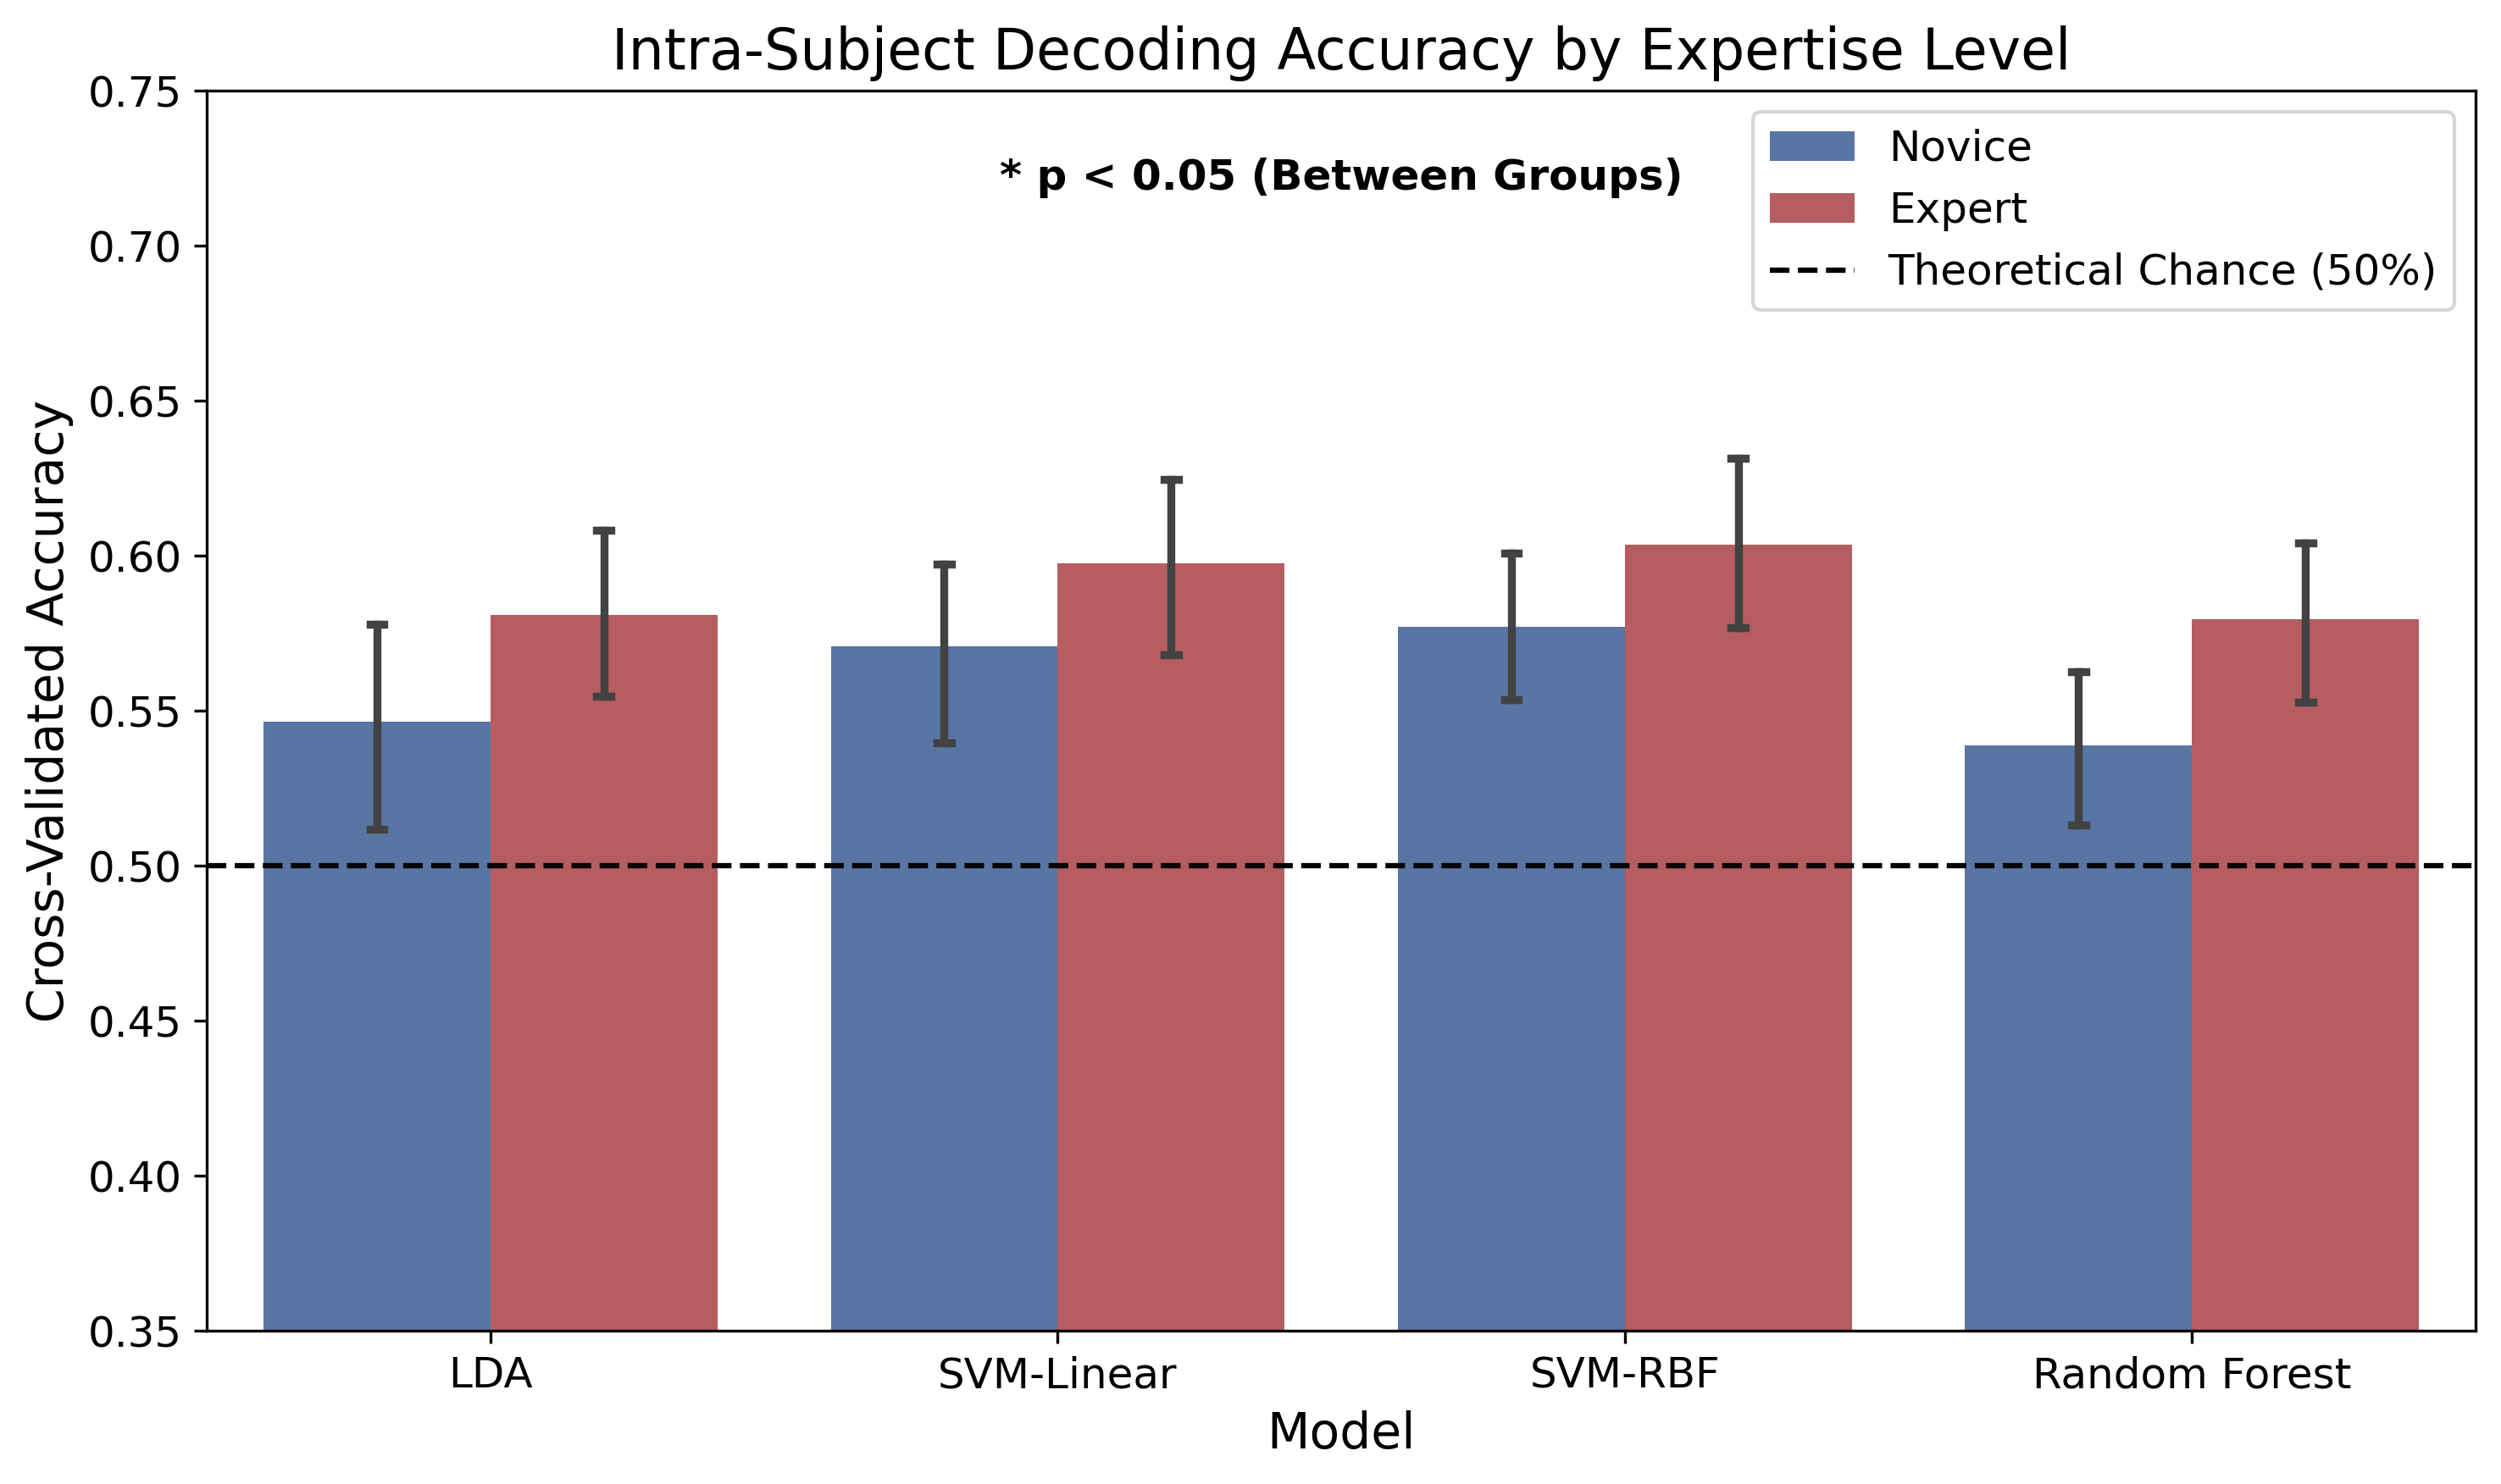

In [20]:
# FIGURE 1: Grouped Accuracy Bar Chart (Experts vs Novices)

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_results, x='Model', y='Accuracy', hue='Expertise',
    palette=['#4C72B0', '#C44E52'], capsize=0.05, ax=ax1, errorbar='ci'
)
ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='Theoretical Chance (50%)')
ax1.set_ylabel("Cross-Validated Accuracy")
ax1.set_ylim(0.35, 0.75)
ax1.set_title("Intra-Subject Decoding Accuracy by Expertise Level")
ax1.legend(loc='upper right')

# ANNOTATING SIGNIFICANCE
plt.text(0.5, 0.92, "* p < 0.05 (Between Groups)", transform=ax1.transAxes, ha='center', fontsize=12, fontweight='bold')

fig1_path = os.path.join(FIG_DIR, "Fig1_Grouped_Accuracy.png")
fig1.tight_layout()
fig1.savefig(fig1_path)
plt.show()

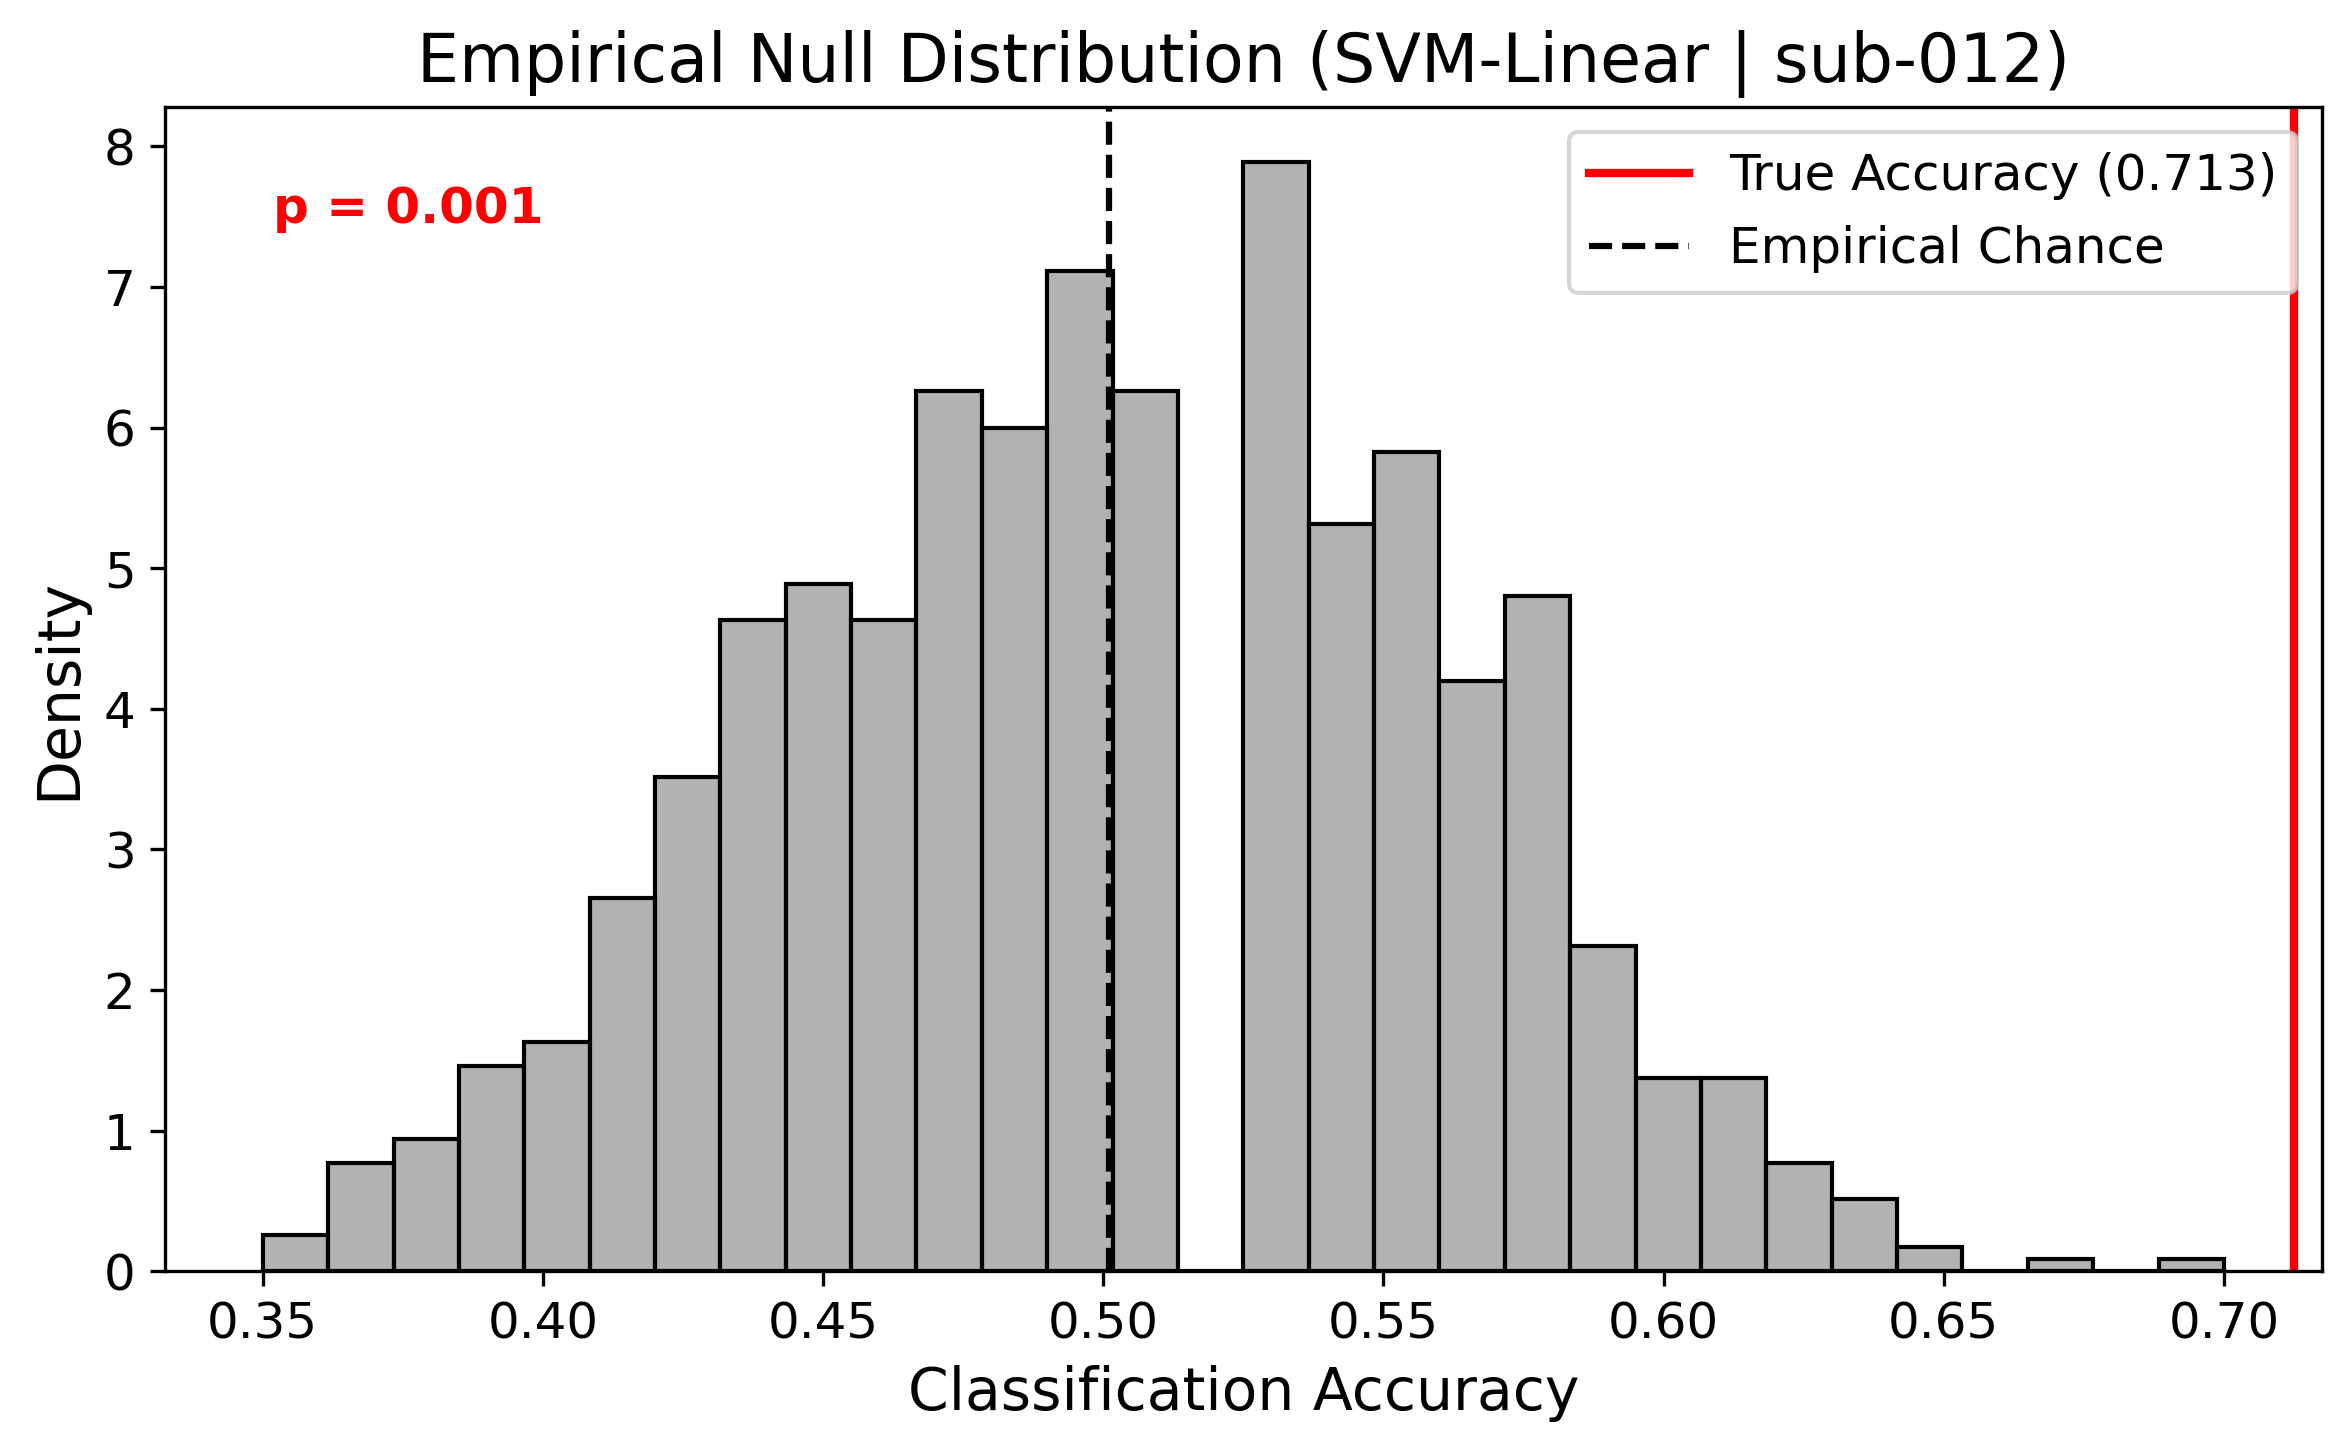

In [21]:
# FIGURE 2: Permutation Null Distribution Histogram

rep_sub = 'sub-012'
rep_model = 'SVM-Linear'

if rep_sub in viz_data and rep_model in viz_data[rep_sub]['models']:
    perm_scores = viz_data[rep_sub]['models'][rep_model]['perm_scores']
    true_acc = viz_data[rep_sub]['models'][rep_model]['accuracy']
    p_val = viz_data[rep_sub]['models'][rep_model]['p_value']

    fig2, ax2 = plt.subplots(figsize=(8, 5))
    sns.histplot(perm_scores, bins=30, color='gray', stat='density', alpha=0.6, ax=ax2)
    ax2.axvline(true_acc, color='red', linestyle='-', linewidth=2, label=f'True Accuracy ({true_acc:.3f})')
    ax2.axvline(np.mean(perm_scores), color='black', linestyle='--', linewidth=1.5, label='Empirical Chance')

    ax2.set_xlabel("Classification Accuracy")
    ax2.set_ylabel("Density")
    ax2.set_title(f"Empirical Null Distribution ({rep_model} | {rep_sub})")
    ax2.legend(loc='upper right')
    ax2.text(0.05, 0.90, f"p = {p_val:.3f}", transform=ax2.transAxes, fontweight='bold', color='red')

    fig2_path = os.path.join(FIG_DIR, "Fig2_Permutation_Histogram.png")
    fig2.tight_layout()
    fig2.savefig(fig2_path)
    plt.show()


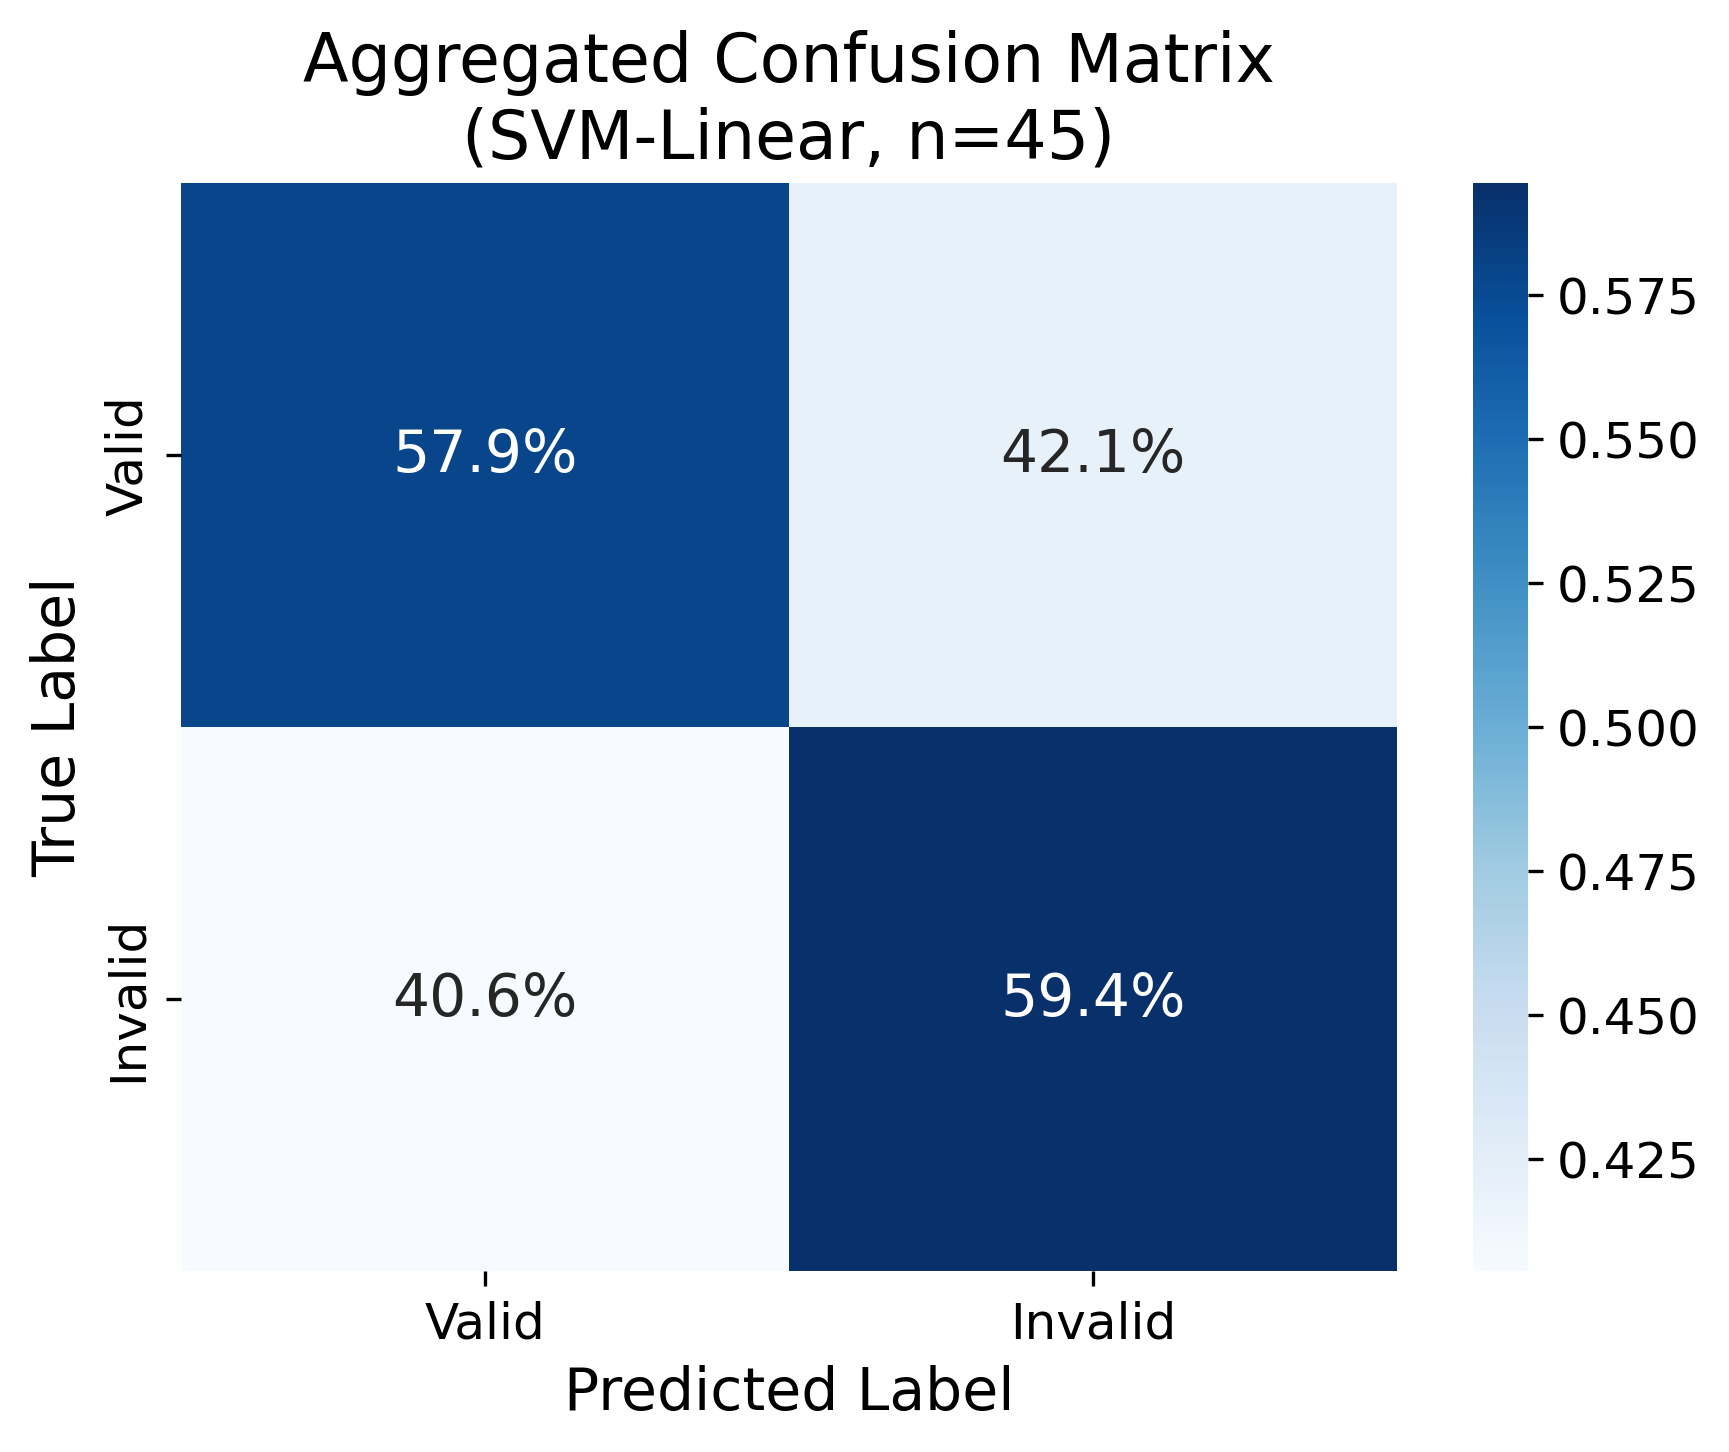


--- VISUALIZATIONS GENERATED AND SAVED TO GOOGLE DRIVE ---


In [22]:
# FIGURE 3: Aggregated Confusion Matrix (SVM-Linear)

cm_sum = np.zeros((2, 2))
valid_subjects = 0

for sub_id, data in viz_data.items():
    if 'SVM-Linear' in data['models']:
        cm_sum += data['models']['SVM-Linear']['confusion_matrix']
        valid_subjects += 1

# Row-normalize to get percentages
cm_norm = cm_sum.astype('float') / cm_sum.sum(axis=1)[:, np.newaxis]

fig3, ax3 = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm, annot=True, fmt=".1%", cmap="Blues", cbar=True,
    xticklabels=['Valid', 'Invalid'], yticklabels=['Valid', 'Invalid'],
    annot_kws={"size": 14}
)
ax3.set_xlabel("Predicted Label")
ax3.set_ylabel("True Label")
ax3.set_title(f"Aggregated Confusion Matrix\n(SVM-Linear, n={valid_subjects})")

fig3_path = os.path.join(FIG_DIR, "Fig3_Aggregated_CM.png")
fig3.tight_layout()
fig3.savefig(fig3_path)
plt.show()

print("\n--- VISUALIZATIONS GENERATED AND SAVED TO GOOGLE DRIVE ---")